# 1) Experimental design figure
## PRISM Paper
#### Written by Shawn Schwartz

---

_Based on code from Waskom et al. (2014)_ 

https://github.com/shawntschwartz/Waskom_JNeurosci_2014/blob/master/Design_Figure.ipynb

---

## import deps

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from matplotlib.font_manager import FontProperties

%matplotlib inline 

## define plotting functions

In [4]:
def make_panels(n_screens, figsize, trial_durations, fixations, goals, labels, double_screen_index,
                stim, stim_screen_index, title, blank_index=None, dpi=900, double_plot_height_scale=13,
                left=.015, top=.88, w=.138, h=.28, w_step=.115, h_step=.025):
    # init empty fig
    fig = plt.figure(figsize=figsize, dpi=300)

    # set params
    ratio = figsize[0] / figsize[1]
    font_prop_titles = FontProperties(family='Arial', weight='bold')
    font_prop_labels = FontProperties(family='Arial')
    screen_width_scale_factor = 0.465
    double_top_offset = 0.0025

    # title
    fig.text(left, top + 0.06, title, size=8, fontproperties=font_prop_titles)

    # make "screens"
    screens = []
    for i in range(n_screens):
        if i == double_screen_index:
            double_left = left - w_step // 2
            double_top = top - h_step * double_plot_height_scale

            fig.text(double_left + w * screen_width_scale_factor, double_top + double_top_offset, 'or', size=6, style='italic', ha='left', va='bottom', fontproperties=font_prop_labels)
            
            ax = fig.add_axes([double_left, double_top - h, w, h], facecolor='w')
            ax.set(xticks=[], yticks=[])
            screens.append(ax)
        else:
            ax = fig.add_axes([left, top - h, w, h], facecolor='w')
            ax.set(xticks=[], yticks=[])

            if i == stim_screen_index-1:
                ax.set_xlim(0, 6)
                ax.set_ylim(0, 6)

            screens.append(ax)

        if i == blank_index - 1:
            screens[i].spines[['right', 'top', 'left', 'bottom']].set_visible(False)
            screens[i].set_facecolor((1.0, 1.0, 1.0, 0.0))

        if i != double_screen_index:
            if i != (blank_index - 1):
                fig.text(left + w, top, trial_durations[i] + ' s', size=6, ha='right', va='bottom', fontproperties=font_prop_labels)
                left += w_step
                top -= h_step

    labels_kws = dict(color='k', ha='center', va='center', weight='bold')

    for i in fixations:
        screens[i].text(.5, .5, '+', size=10, **labels_kws)

    if double_screen_index is not None:
        double_screen_index += 2

        for i in goals:
            double_screen_index -= 1
            screens[double_screen_index].text(.5, .5, i, size=6, name='Arial', **labels_kws)

        for i, label in enumerate(labels):
            double_screen_index -= 1
            shifted_left = left * 0.5
            if i == 1:
                double_screen_index += 1
                shifted_top = top - 2.125
            elif i == 3:
                shifted_top = top - 2.9
            else:
                shifted_top = top - 0.975

            if double_screen_index == 4:
                shifted_left -= 0.15
            
            screens[double_screen_index].text(shifted_left, shifted_top, label, size=6, fontproperties=font_prop_labels)
            double_screen_index += 2
    else:
        top -= 0.95
        left = 0.2375 + 0.25
        
        for i, label in enumerate(labels):
            top_offset = 0
            left_offset = 0
            
            if i == 4:
                top_offset = -1
                left_offset = 2.5

            shifted_top = top + top_offset
            shifted_left = left + left_offset
            
            screens[i].text(shifted_left, shifted_top, label, size=6, ha='center', fontproperties=font_prop_labels)

    ret_axes_one = [-1.85, 0, 4.15, 1]
    ret_axes_two = [-0.05, 0, 1, 1]
    
    if title == 'Retrieval':
        ax = fig.add_axes([0.2375 * 0.5475, h - 0.2, w, h], facecolor='w')
        ax.set(xticks=[], yticks=[])
        screens.append(ax)

        # (left, bottom, width, height)
        ax = fig.add_axes(ret_axes_one)
        ax.set_axis_off()
        fig.text(left-0.2185, 0.36, '1.5-2.5 s', size=6, ha='right', va='bottom', fontproperties=font_prop_labels)

        arrow_kws = dict(arrowstyle='->', mutation_scale=12, lw=1)
        
        arrow_down = mpl.patches.FancyArrowPatch(posA=(0.425, 0.52), posB=(0.425, 0.35), **arrow_kws)
        ax.add_artist(arrow_down)

        arrow_curved = mpl.patches.FancyArrowPatch(posA=(0.22, 0.2), posB=(0.07, 0.552), connectionstyle='arc3,rad=-.25', **arrow_kws)
        ax.add_artist(arrow_curved)

        arrow_repeat = mpl.patches.FancyArrowPatch(posA=(0.56, 0.848), posB=(0.28, 0.848), connectionstyle='arc3,rad=.425', **arrow_kws)
        ax.add_artist(arrow_repeat)

        ax.set_aspect('equal')
        
        ctrl_circle = mpl.patches.CirclePolygon((0.422, 0.22), 0.07, resolution=100, color='#d1ccc6', linewidth=0)
        ax.add_artist(ctrl_circle)
        
        reorienting_circle = mpl.patches.CirclePolygon((0.7715, 0.69), 0.07, resolution=100, edgecolor='black', facecolor='none', linestyle=':', lw=0.75)
        ax.add_artist(reorienting_circle)
        
        ax.text(0.425, 0.055, 'Real-time trial recovery', size=6, ha='center', va='top', color='.1', fontproperties=font_prop_labels)

        arrow_labels_kws = dict(size=4.5, color='.1', ha='center', bbox=dict(facecolor='white', edgecolor='white', alpha=1, pad=1), fontproperties=font_prop_labels)
        ax.text(0.095, 0.345, 'Recycle trial\n(up to 3x)', **arrow_labels_kws)
        ax.text(0.425, 0.43, 'Abort trial\n(dummy probe)', **arrow_labels_kws)
        ax.text(0.425, 0.875, 'Repeat\n(up to 1x)', **arrow_labels_kws)

        rect_kws = dict(boxstyle='square,pad=0.008', lw=0)
        
        rect_colors = {
            'baseline': '#cd83ef',
            'threshold': '#f8933f',
            'trigger': '#ed4c89',
            'pupilepoch': '#39c6d7',
        }

        rect_baseline = mpl.patches.FancyBboxPatch((0.07925, 0.865), 0.192, 0.004, fc=rect_colors.get('baseline'), **rect_kws)
        rect_baseline_legend = mpl.patches.FancyBboxPatch((0.001, 0.27), 0.05, 0.004, fc=rect_colors.get('baseline'), **rect_kws)
        
        rect_threshold = mpl.patches.FancyBboxPatch((0.2209, 0.839), 0.401, 0.005, fc=rect_colors.get('threshold'), **rect_kws)
        rect_threshold_legend = mpl.patches.FancyBboxPatch((0.001, 0.22), 0.05, 0.005, fc=rect_colors.get('threshold'), **rect_kws)

        rect_trigger = mpl.patches.FancyBboxPatch((0.571, 0.814), 0.40, 0.004, fc=rect_colors.get('trigger'), **rect_kws)
        rect_trigger_legend = mpl.patches.FancyBboxPatch((0.001, 0.17), 0.05, 0.004, fc=rect_colors.get('trigger'), **rect_kws)
        
        rect_pupilepoch = mpl.patches.FancyBboxPatch((0.2375, 0.789), 0.398, 0.004, fc=rect_colors.get('pupilepoch'), **rect_kws)
        rect_pupilepoch_legend = mpl.patches.FancyBboxPatch((0.001, 0.12), 0.05, 0.004, fc=rect_colors.get('pupilepoch'), **rect_kws)

        legend_kws = dict(size=4.75, color='.1', fontproperties=font_prop_labels)
        
        ax.text(0.76, 0.2625, r'Trials 1-20: Construct baseline in real time (2-s tonic pupil assay)', **legend_kws)
        ax.text(0.76, 0.2125, r'Trials 21+: Detect lapsing in real time ( $\overline{pupil} \notin [\mu - \sigma, \mu + \sigma]$ )', **legend_kws)
        ax.text(0.7625, 0.1625, r'Trials 21+: Trigger reorienting cue in real time (if lapsed)', **legend_kws)
        ax.text(0.7625, 0.1125, r'Trials 21+: Assay tonic pupil size offline', **legend_kws)
        
        ax.add_patch(rect_baseline)
        ax.add_patch(rect_threshold)
        ax.add_patch(rect_trigger)

        ax = fig.add_axes(ret_axes_two)
        ax.set_axis_off()
        ax.set_aspect('equal')

        ax.add_patch(rect_pupilepoch)
        ax.add_patch(rect_baseline_legend)
        ax.add_patch(rect_threshold_legend)
        ax.add_patch(rect_trigger_legend)
        ax.add_patch(rect_pupilepoch_legend)
        
    else:
        ax = fig.add_axes(ret_axes_one)
        ax.set_aspect('equal')
        ax.set_axis_off()

        ax = fig.add_axes(ret_axes_two)
        ax.set_axis_off()
        ax.set_aspect('equal')
            
    img = np.asarray(Image.open(stim))
    image_extent = [2, 4, 2, 4]
    screens[stim_screen_index-1].imshow(img, extent=image_extent, aspect='auto')

    return fig, ax


def round_pupil(val):
    if val % 100 >= 50:
        return ((val + 99) // 100) * 100
    else:
        return (val // 100) * 100


def render_stacked_figure(p1, ax1, p2, ax2, dpi=900):
    fig, axs = plt.subplots(2, 1, figsize=(2, 1.5), dpi=dpi)
    ax1.figure.canvas.print_figure('tmp_fig1.png')
    img1 = plt.imread('tmp_fig1.png')
    axs[0].imshow(img1, aspect='equal')
    axs[0].axis('off')
    axs[0].set_xlim(0, 1300)
    
    ax2.figure.canvas.print_figure('tmp_fig2.png')
    img2 = plt.imread('tmp_fig2.png')
    axs[1].imshow(img2, aspect='equal')
    axs[1].axis('off')
    axs[1].set_xlim(0, 1300)

    plt.subplots_adjust(left=0, bottom=0, right=2.5, top=2.5, wspace=0, hspace=-0.15)

    font_prop_labels = FontProperties(family='Arial', weight='bold')
    labels_kws = dict(fontsize=4, va='top', ha='right', fontproperties=font_prop_labels)
    title_kws = dict(fontsize=5, va='top', fontproperties=font_prop_labels)

    plt.savefig('../plots/prism_task_design.tiff', dpi=dpi, bbox_inches='tight')

    # clean up tmp files
    #for i in range(2):
        #os.remove(f'tmp_fig{i+1}.png')

## encoding phase panel

In [7]:
p1, ax1 = make_panels(
    n_screens=6,
    figsize=(6.85, 2.25),
    trial_durations=['4.0', '1.6', '1.6', '0.1', '2.8', ' '],
    fixations=[0, 3],
    goals=['Bigger/\nSmaller?', 'Pleasant/\nUnpleasant?'],
    labels=['Pre-goal/ITI', 'Learning goal', 'Pre-probe/ITI', '        Probe (big/sm)\n                   (pl/unpl)'],
    double_screen_index=1,
    stim='../experiments/1-prism/stimuli/207.jpg',
    stim_screen_index=5,
    blank_index=6,
    title='Encoding'
)

## retrieval phase panel

In [10]:
p2, ax2 = make_panels(
    n_screens=5,
    figsize=(6.85, 2.25),
    trial_durations=['4.0', '1.0', '0.4', '1.0', '≤ 5.0'],
    fixations=[0, 1, 2, 3],
    goals=None,
    labels=['Baseline assay/ITI   ', 'Lapsing assay/ITI  ', 'Trigger cue/ITI', 'Pre-probe/ITI', 'Probe (4-AFC)'],
    double_screen_index=None,
    stim='../experiments/1-prism/stimuli/207.jpg',
    stim_screen_index=5,
    blank_index=999,
    title='Retrieval'
)

## stitch panels into final design figure

In [13]:
render_stacked_figure(p1, ax1, p2, ax2)

## memory classification grid panel

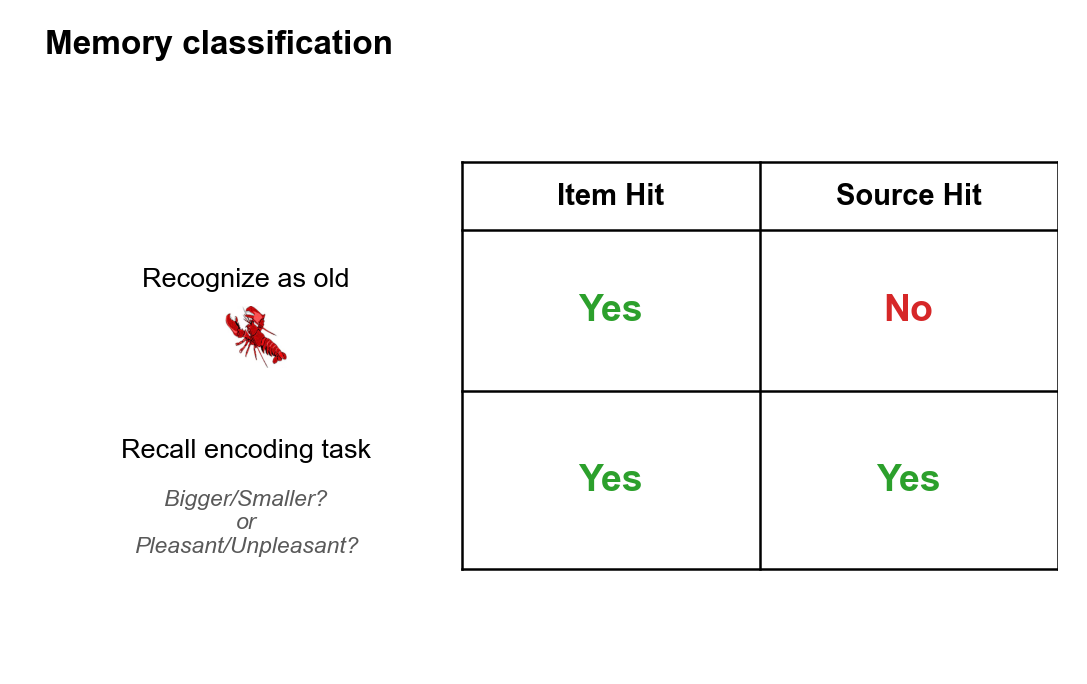

In [76]:
# Memory classification grid
fig = plt.figure(figsize=(3.425, 2.25), dpi=300)
font_prop_titles = FontProperties(family='Arial', weight='bold')
font_prop_labels = FontProperties(family='Arial')

ax = fig.add_axes([0.0, 0.05, 1.0, 0.88])
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_axis_off()

fig.text(0.015, 0.94, 'Memory classification', size=8, fontproperties=font_prop_titles)

# --- Grid boundaries ---
gl, gr = 4.2, 10.0   # grid left / right
cm = 7.1              # column midpoint
gt = 5.8              # grid top
hb = 5.0              # header bottom
rm = 3.1              # row midpoint
gb = 1.0              # grid bottom

lw = 0.6
for y in [gt, hb, rm, gb]:
    ax.plot([gl, gr], [y, y], 'k', lw=lw)
for x in [gl, cm, gr]:
    ax.plot([x, x], [gb, gt], 'k', lw=lw)

# --- Column headers ---
ix = (gl + cm) / 2    # item column center x
sx = (cm + gr) / 2    # source column center x
hy = (hb + gt) / 2    # header center y

ax.text(ix, hy, 'Item Hit', size=7, ha='center', va='center', fontproperties=font_prop_titles)
ax.text(sx, hy, 'Source Hit', size=7, ha='center', va='center', fontproperties=font_prop_titles)

# --- Row centers ---
r1y = (hb + rm) / 2   # row 1 center y
r2y = (rm + gb) / 2   # row 2 center y

# --- Row labels ---
# Row 1: Recognize as old
ax.text(2.1, r1y, 'Recognize as old\n\n', size=6.5, ha='center', va='center',
        fontproperties=font_prop_labels, linespacing=1.4)

# Row 2: Recall source (perceptual or conceptual)
ax.text(2.1, r2y + 0.35, 'Recall encoding task', size=6.5, ha='center', va='center',
        fontproperties=font_prop_labels)
ax.text(2.1, r2y - 0.5, 'Bigger/Smaller?\nor\nPleasant/Unpleasant?',
        size=5.5, ha='center', va='center', style='italic', color='.35',
        fontproperties=font_prop_labels, linespacing=1.2)

# --- Cell values ---
ckws = dict(ha='center', va='center', fontproperties=font_prop_titles)
ax.text(ix, r1y, 'Yes', size=9, color='#2ca02c', **ckws)   # Item: Recognize = Yes
ax.text(ix, r2y, 'Yes', size=9, color='#2ca02c', **ckws)     # Item: Recall source = No
ax.text(sx, r1y, 'No', size=9, color='#d62728', **ckws)    # Source: Recognize = Yes
ax.text(sx, r2y, 'Yes', size=9, color='#2ca02c', **ckws)    # Source: Recall source = Yes

# --- Stimulus thumbnail next to "Recognize as old" label ---
img = np.asarray(Image.open('../experiments/1-prism/stimuli/207.jpg'))
ax_img = fig.add_axes([0.19, 0.45, 0.06, 0.14])
ax_img.imshow(img)
ax_img.set(xticks=[], yticks=[])
for sp in ax_img.spines.values():
    sp.set_linewidth(0.0)

plt.savefig('../plots/prism_memory_classification.tiff', dpi=900, bbox_inches='tight')
plt.show()

## session info

In [6]:
from IPython import sys_info
from IPython.display import JSON
import json

info = sys_info()

if isinstance(info, str):
    safe = {"sys_info": info}
else:
    safe = {k: str(v) for k, v in info.items()}

JSON(safe)

<IPython.core.display.JSON object>